In [1]:
from preamble_jax import *

Available devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3), CpuDevice(id=4), CpuDevice(id=5), CpuDevice(id=6), CpuDevice(id=7)]
CPU devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3), CpuDevice(id=4), CpuDevice(id=5), CpuDevice(id=6), CpuDevice(id=7)]


2026-03-20 11:04:28,690 - WARNING - File .dacerc not found. You are requesting data in public mode. To change this behaviour, create a .dacerc file in your home directory and fill it with your API key. More infos on https://dace.unige.ch
/opt/anaconda3/envs/pyjax312/lib/python3.12/site-packages/chromatic/imports.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import copy, pkg_resources, os, glob, pickle


BT-Settl grid shape: unknown
NaN count in grid: unknown


🌈🤖 The time scale for this rainbow is '?',
and there are 160 time centers and
160 time edges defined.

It's hard to imshow something with a time axis
that isn't linearly or logarithmically uniform, or doesn't
at least have its time edges defined. We're giving up
and just using the time index as the time axis.

If you want a real time axis, one solution would be
to use `rainbow.pcolormesh()` instead of `rainbow.imshow()`.
It takes basically the same inputs but can handle non-uniform
grids.

Or, you could bin your times to a more uniform grid with
`binned = rainbow.bin(dt=...)` (for linear times) and then
`binned.imshow()` will give more informative axes.



  0%|          | 0/138 [00:00<?, ?it/s]

  0%|          | 0/110 [00:00<?, ?it/s]

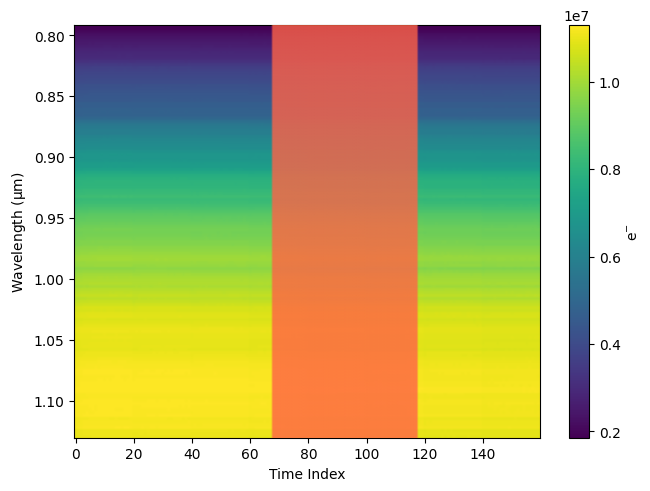

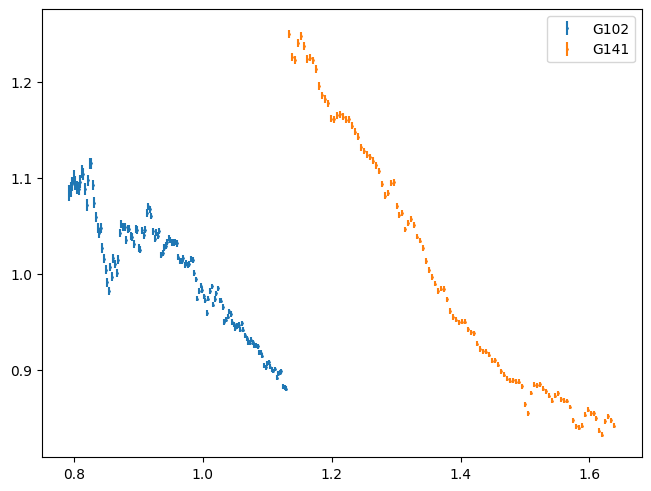

<Figure size 640x480 with 0 Axes>

In [2]:
visit = 'S22'
err_factor = S22_SED_err_factor

'Things that automatically get re-defined for either visit'
predicted_T0 = visits[f'{visit}']['T0 (BJD_TDB)'].value
binwidth = visits[f'{visit}']['native resolution']
exptime = visits[f'{visit}']['exp (s)']
grism = visits[f'{visit}']['Grism']
rainbow = read_rainbow(f"../../data/rainbows/{visit}_scan-combined_trimmed_pacman_spec.rainbow.npy")
speclc_rainbow = rainbow

'Adjust uncertainties and bin the rainbow'
# for i in range(len(rainbow.wavelength.value)):
#     speclc_rainbow.uncertainty[i,:] = rainbow.uncertainty[i,:] #* err_factor[i]

'remove the transit'
out_of_transit = ( speclc_rainbow.trim().mask_transit(period=8.463*u.day, t0=predicted_T0*u.day, duration=0.15*u.day) )

out_of_transit.imshow()
'define the appropriate arrays'
_meanOOTspec = out_of_transit.get_average_spectrum_as_rainbow()
meanOOTspec = _meanOOTspec.flux
meanOOTspec_relative_err = _meanOOTspec.uncertainty.value/meanOOTspec.value
oot_spec_err = meanOOTspec_relative_err.flatten()
_SED_wavelengths = (_meanOOTspec.wavelength.value).flatten()
e_per_s = meanOOTspec / exptime
e_per_s_per_angstrom = e_per_s / binwidth
_w, _s, _e = read_sensitivity_curve(grism=grism)
binned_filter_response = bintogrid(_w.value, _s.value, newx=_SED_wavelengths)['y'] * u.cm**2 / u.erg
_calibrated_mean_spec = e_per_s_per_angstrom.flatten() / binned_filter_response
calibrated_mean_spec = _calibrated_mean_spec.value/np.nanmean(_calibrated_mean_spec.value)
oot_spec_err = oot_spec_err * calibrated_mean_spec

# Convert to JAX arrays
calibrated_mean_spec_G102 = jnp.array(calibrated_mean_spec)
oot_spec_err_G102 = jnp.array(oot_spec_err)
SED_wavelengths_G102 = jnp.array(_SED_wavelengths)

visit = 'F21'
err_factor = F21_SED_err_factor

'Things that automatically get re-defined for either visit'
predicted_T0 = visits[f'{visit}']['T0 (BJD_TDB)'].value
binwidth = visits[f'{visit}']['native resolution']
exptime = visits[f'{visit}']['exp (s)']
grism = visits[f'{visit}']['Grism']
rainbow = read_rainbow(f"../../data/rainbows/{visit}_scan-combined_trimmed_pacman_spec.rainbow.npy")
speclc_rainbow = rainbow

'Adjust uncertainties and bin the rainbow'
# for i in range(len(rainbow.wavelength.value)):
#     speclc_rainbow.uncertainty[i,:] = rainbow.uncertainty[i,:] #* err_factor[i]

'remove the transit'
out_of_transit = ( speclc_rainbow.trim().mask_transit(period=8.463*u.day, t0=predicted_T0*u.day, duration=0.15*u.day) )

'define the appropriate arrays'
_meanOOTspec = out_of_transit.get_average_spectrum_as_rainbow()
meanOOTspec = _meanOOTspec.flux
meanOOTspec_relative_err = _meanOOTspec.uncertainty.value/meanOOTspec.value
_oot_spec_err = meanOOTspec_relative_err.flatten()
_SED_wavelengths = (_meanOOTspec.wavelength.value).flatten()
e_per_s = meanOOTspec / exptime
e_per_s_per_angstrom = e_per_s / binwidth
_w, _s, _e = read_sensitivity_curve(grism=grism)
binned_filter_response = bintogrid(_w.value, _s.value, newx=_SED_wavelengths)['y'] * u.cm**2 / u.erg
_calibrated_mean_spec = e_per_s_per_angstrom.flatten() / binned_filter_response
calibrated_mean_spec = _calibrated_mean_spec.value/np.nanmean(_calibrated_mean_spec.value)
oot_spec_err = _oot_spec_err * calibrated_mean_spec

# Convert to JAX arrays
calibrated_mean_spec_G141 = jnp.array(calibrated_mean_spec)
oot_spec_err_G141 = jnp.array(oot_spec_err)
SED_wavelengths_G141 = jnp.array(_SED_wavelengths)

plt.figure()
plt.errorbar(SED_wavelengths_G102,calibrated_mean_spec_G102,yerr=oot_spec_err_G102*100,fmt='o',label='G102',ms=1)
plt.errorbar(SED_wavelengths_G141,calibrated_mean_spec_G141,yerr=oot_spec_err_G141*100,fmt='o',label='G141',ms=1)
plt.legend()
plt.show()
plt.clf()

In [ ]:
def numpyro_model(N_temps=2, return_max_likelihood=False):
    """
    Define the probabilistic model in NUMPYRO with N_temps components.
    
    Args:
        N_temps: Number of temperature components (1, 2, 3, or 4)
        return_max_likelihood: If True, also return the maximum log likelihood value
    """
    def model():
        temp_bounds = [
            (3600, 4300),   # T1 bounds (higher temperature)
            (3200, 3600),   # T2 bounds (cooler component)
            (4300, 10000),  # T3 bounds 
            (2600, 3200)    # T4 bounds
        ]
        
        # Sample temperatures
        T_samples = []
        for i in range(1, N_temps + 1):
            T = numpyro.sample(f'T{i}', dist.Uniform(*temp_bounds[i-1]))
            T_samples.append(T)
        
        # Sample scale factors for components 2..N
        ff_samples = [1.0]  # First component always has f=1
        for i in range(2, N_temps + 1):
            ff = 10**numpyro.sample(f'ff{i}', dist.Uniform(-4, 2))
            ff_samples.append(ff)

        # Other parameters
        offset_G102 = numpyro.sample('offset_G102', dist.Uniform(0.0, 0.8))
        slope_G141 = numpyro.sample('slope_G141', dist.Uniform(-1.0, 0.6))
        slope_G102 = numpyro.sample('slope_G102', dist.Uniform(-1.0, 0.6))

        sigma_conv = 1.0
        beta_102 = numpyro.sample('beta_G102', dist.Uniform(2.0, 2.7))
        beta_141 = numpyro.sample('beta_G141', dist.Uniform(2.0, 2.7))

        # NEW: Sample BOTH metallicity AND logg
        metallicity = numpyro.sample('metallicity', dist.Uniform(0.0, 0.5))
        logg = 4.5 #numpyro.sample('logg', dist.Uniform(3.5, 5.0))  # Typical BT-Settl range

        # Adjust and concatenate data with slopes applied
        offset_102 = jnp.asarray(offset_G102, dtype=jnp.float64)
        
        # Apply offset and slope to G102 data
        spec_G102_with_offset = jnp.array(calibrated_mean_spec_G102 + offset_102)
        
        # Apply the slopes
        spec_G102_with_slope = spec_G102_with_offset + slope_G102 * (SED_wavelengths_G102 - SED_wavelengths_G102[0])
        spec_G141_with_slope = jnp.array(calibrated_mean_spec_G141) + slope_G141 * (SED_wavelengths_G141 - SED_wavelengths_G141[0])
        
        # Concatenate the spectra
        _spec_flux_jax = jnp.concatenate([spec_G102_with_slope, spec_G141_with_slope])
        
        spec_flux_jax = _spec_flux_jax / jnp.mean(_spec_flux_jax)
        spec_err_jax = jnp.concatenate(
            [
                jnp.array((10**beta_102) * oot_spec_err_G102),
                jnp.array((10**beta_141) * oot_spec_err_G141)
            ]
        )
        combined_SED_wavelengths = jnp.concatenate([jnp.array(SED_wavelengths_G102), 
                                                    jnp.array(SED_wavelengths_G141)])
        
        @jit
        def decomp_model(temps, scales, metal_val, logg_val, sigma):
            # Get spectra for all temperatures with variable metallicity AND logg
            spectra = [get_BTSettl_spectrum_jax(T=Temp, logg=logg_val, metallicity=metal_val) 
                       for Temp in temps]
            
            # Calculate combined spectrum with scaling factors
            flux_combined = scales[0] * spectra[0][1]  # Start with first component
            for i in range(1, N_temps):
                flux_combined += scales[i] * spectra[i][1]
            
            # Normalize
            _model_flux = flux_combined / jnp.mean(flux_combined)
            
            # Convolve and bin
            convolved = convolve_spectrum_jax(
                panchromatic_wavelengths, 
                _model_flux, 
                sigma=jnp.asarray(sigma, dtype=jnp.float64)
            )
            binned_model_flux = shone.bin_spectrum(
                combined_SED_wavelengths, 
                panchromatic_wavelengths, 
                convolved
            )
            model_flux = binned_model_flux / jnp.mean(binned_model_flux)
            
            return model_flux

        # Calculate model flux with both metallicity AND logg
        model_flux = decomp_model(T_samples, ff_samples, metallicity, logg, sigma_conv)
        
        # Add a small epsilon to avoid numerical issues
        eps = 1e-10
        safe_spec_err = jnp.maximum(spec_err_jax, eps)
        
        # Define the likelihood
        log_likelihood = dist.Normal(model_flux, safe_spec_err).log_prob(spec_flux_jax).sum()
        
        # Add a prior on log likelihood to catch NaN values
        log_likelihood = jnp.where(jnp.isnan(log_likelihood), -1e10, log_likelihood)
        
        # Sample the observed data
        numpyro.sample("Obs", dist.Normal(model_flux, safe_spec_err), obs=spec_flux_jax)
        
        # Track log likelihood for maximum likelihood calculation
        if return_max_likelihood:
            numpyro.deterministic('log_likelihood', log_likelihood)
    
    if return_max_likelihood:
        def get_max_likelihood(samples):
            """Extract maximum log likelihood from samples"""
            log_lik_samples = samples.get('log_likelihood', None)
            if log_lik_samples is not None:
                return float(jnp.max(log_lik_samples))
            return None
        
        return model, get_max_likelihood
    else:
        return model

In [4]:
# def numpyro_model(N_temps=2, return_max_likelihood=False):
#     """
#     Define the probabilistic model in NUMPYRO with N_temps components.
    
#     Args:
#         N_temps: Number of temperature components (1, 2, 3, or 4)
#         return_max_likelihood: If True, also return the maximum log likelihood value
#     """
#     # This function is the actual model that NumPyro will call
#     def model():
#         temp_bounds = [
#             (3600, 4300),   # T1 bounds (higher temperature)
#             (3200, 3600),   # T2 bounds (cooler component)
#             (4300, 10000),   # T3 bounds 
#             (2600, 3200)    # T4 bounds
#         ]
        
#         # Sample temperatures
#         T_samples = []
#         for i in range(1, N_temps + 1):
#             # if i == 2:
#             #     delta_T = numpyro.sample('delta_T', dist.Uniform(-1000,0))
#             #     T = numpyro.deterministic(f'T{i}', T_samples[0] + delta_T)
#             # else:
#             T = numpyro.sample(f'T{i}', dist.Uniform(*temp_bounds[i-1]))
            
#             T_samples.append(T)
        
#         # Sample scale factors for components 2..N
#         ff_samples = [1.0]  # First component always has f=1
#         for i in range(2, N_temps + 1):
#             ff = 10**numpyro.sample(f'ff{i}', dist.Uniform(-4, 2))
#             ff_samples.append(ff)

#         # Other parameters
#         offset_G102 = numpyro.sample('offset_G102', dist.Uniform(0.0, 0.8))
#         slope_G141 = numpyro.sample('slope_G141', dist.Uniform(-1.0, 0.6))
#         slope_G102 = numpyro.sample('slope_G102', dist.Uniform(-1.0, 0.6)) #2*slope_G141

#         sigma_conv = 1.0 #numpyro.sample('sigma_conv', dist.Uniform(1, 20))
#         beta_102 = numpyro.sample('beta_G102', dist.Uniform(2.0, 2.7))
#         beta_141 = numpyro.sample('beta_G141', dist.Uniform(2.0, 2.7))

#         metal = numpyro.sample('metallicity', dist.Uniform(-0.5, 0.5))

#         # Adjust and concatenate data with slopes applied
#         offset_102 = jnp.asarray(offset_G102, dtype=jnp.float64)
        
#         # Apply offset and slope to G102 data (slope applied as function of index position)
#         spec_G102_with_offset = jnp.array(calibrated_mean_spec_G102 + offset_102)
        
#         # Apply the slopes
#         spec_G102_with_slope = spec_G102_with_offset + slope_G102 * (SED_wavelengths_G102-SED_wavelengths_G102[0])
#         spec_G141_with_slope = jnp.array(calibrated_mean_spec_G141) + slope_G141 * (SED_wavelengths_G141-SED_wavelengths_G141[0])
        
#         # Concatenate the spectra
#         _spec_flux_jax = jnp.concatenate([spec_G102_with_slope, spec_G141_with_slope])
        
#         spec_flux_jax = _spec_flux_jax / jnp.mean(_spec_flux_jax)
#         spec_err_jax = jnp.concatenate(
#             [
#                 jnp.array((10**beta_102) * oot_spec_err_G102),
#                 jnp.array((10**beta_141) * oot_spec_err_G141)
#             ]
#         )
#         combined_SED_wavelengths = jnp.concatenate([jnp.array(SED_wavelengths_G102), 
#                                                     jnp.array(SED_wavelengths_G141)])
        
#         @jit
#         def decomp_model(temps, scales, sigma):
#             # Get spectra for all temperatures
#             spectra = [get_BTSettl_spectrum_jax(T=Temp, logg=4.5, metallicity=metal) 
#                        for Temp in temps]
            
#             # Calculate combined spectrum with scaling factors
#             flux_combined = scales[0] * spectra[0][1]  # Start with first component
#             for i in range(1, N_temps):
#                 flux_combined += scales[i] * spectra[i][1]
            
#             # Normalize
#             _model_flux = flux_combined / jnp.mean(flux_combined)
            
#             # Convolve and bin
#             convolved = convolve_spectrum_jax(
#                 panchromatic_wavelengths, 
#                 _model_flux, 
#                 sigma=jnp.asarray(sigma, dtype=jnp.float64)
#             )
#             binned_model_flux = shone.bin_spectrum(
#                 combined_SED_wavelengths, 
#                 panchromatic_wavelengths, 
#                 convolved
#             )
#             model_flux = binned_model_flux / jnp.mean(binned_model_flux)
            
#             return model_flux

#         # Calculate model flux
#         model_flux = decomp_model(T_samples, ff_samples, sigma_conv)
        
#         # Define the likelihood
#         log_likelihood = dist.Normal(model_flux, spec_err_jax).log_prob(spec_flux_jax).sum()
        
#         # Sample the observed data
#         numpyro.sample("Obs", dist.Normal(model_flux, spec_err_jax), obs=spec_flux_jax)
        
#         # Track log likelihood for maximum likelihood calculation
#         if return_max_likelihood:
#             numpyro.deterministic('log_likelihood', log_likelihood)
    
#     # If we want to return the max likelihood callback
#     if return_max_likelihood:
#         def get_max_likelihood(samples):
#             """Extract maximum log likelihood from samples"""
#             log_lik_samples = samples.get('log_likelihood', None)
#             if log_lik_samples is not None:
#                 return float(jnp.max(log_lik_samples))
#             return None
        
#         return model, get_max_likelihood
#     else:
#         return model

In [5]:
rng_seed = 0

def hstack_recursive(final_states, checkpoint_states):
    for key in final_states.keys():
        if isinstance(final_states[key], dict):
            hstack_recursive(final_states[key], checkpoint_states[key])
        else:
            final_states[key] = jnp.hstack([
                final_states[key], 
                checkpoint_states[key]
            ])

def print_big_message(big_message):
    print('\n\n')
    print('=' * len(big_message))
    print(big_message)
    print('=' * len(big_message))
    print('\n\n')

def post_batch_viz_save(self, **kwargs):
    """
    here we define some tasks to do after each completed checkpoint:
    """
    print(f'Corner for checkpoint {self.checkpoint}')

    samples_cumulative = self.get_samples()
    corner.corner(samples_cumulative)
    plt.suptitle(f'checkpoint {self.checkpoint}')
    plt.savefig(f'../../figs/joint-visit_chkpt_{self.checkpoint}_sed_corner.png', dpi=200)
    plt.show()
    plt.clf()
    
    # EXTRACT MEDIAN PARAMETERS DIRECTLY FROM SAMPLES (like corner plot does)
    chkpt_median_params = {}
    for param_name, param_samples in samples_cumulative.items():
        # param_samples has shape (num_chains, num_samples)
        # Flatten across chains and compute median
        flattened_samples = param_samples.flatten()
        chkpt_median_params[param_name] = float(jnp.median(flattened_samples))
    
    print("Median parameters from samples:")
    for param, value in chkpt_median_params.items():
        print(f"  {param}: {value:.6f}")
    
    # Calculate and print maximum log likelihood
    if 'log_likelihood' in samples_cumulative:
        log_lik_samples = samples_cumulative['log_likelihood'].flatten()
        max_log_lik = float(jnp.max(log_lik_samples))
        print(f"Maximum log likelihood: {max_log_lik:.6f}")
        
        # Also compute Bayesian Information Criterion (BIC) if you want
        n_params = len([p for p in samples_cumulative.keys() if p != 'log_likelihood'])
        n_data = len(SED_wavelengths_G102) + len(SED_wavelengths_G141)  # number of data points
        bic = -2 * max_log_lik + n_params * jnp.log(n_data)
        print(f"BIC: {bic:.6f}")

    with open(f'../../data/samples/samples_cumulative_{self.start_time}_checkpoint_{self.checkpoint:04d}.pkl', 'wb') as file:
        pickle.dump(dict(samples_cumulative), file)

class MCMCWithCheckpoints(MCMC):
    running_states = None
    checkpoint = 0
    start_time = None
    
    def run_checkpoints(self, rng_key, *args, extra_fields=(), n_checkpoints=10, 
                        progress_bar_warmup=True, progress_bar_samples=True, 
                        init_params=None, on_checkpoint=None, **kwargs):
        """
        Run the MCMC samplers and collect samples.

        :param random.PRNGKey rng_key: Random number generator key to be used for the sampling.
            For multi-chains, a batch of `num_chains` keys can be supplied. If `rng_key`
            does not have batch_size, it will be split in to a batch of `num_chains` keys.
        :param args: Arguments to be provided to the :meth:`numpyro.infer.mcmc.MCMCKernel.init` method.
            These are typically the arguments needed by the `model`.
        :param extra_fields: Extra fields (aside from `"z"`, `"diverging"`) from the
            state object (e.g. :data:`numpyro.infer.hmc.HMCState` for HMC) to be collected
            during the MCMC run. Note that subfields can be accessed using dots, e.g.
            `"adapt_state.step_size"` can be used to collect step sizes at each step. Exclude sample sites from
            collection with "~`sampler.sample_field`.`sample_site`". e.g. "~z.a" will prevent site "a" from
            being collected if you're using the NUTS sampler. To collect samples of a site "a" in the
            unconstrained space, we can specify the variable here, e.g. `extra_fields=("z.a",)`.
        :type extra_fields: tuple or list of str
        :param init_params: Initial parameters to begin sampling. The type must be consistent
            with the input type to `potential_fn` provided to the kernel. If the kernel is
            instantiated by a numpyro model, the initial parameters here correspond to latent
            values in unconstrained space.
        :param kwargs: Keyword arguments to be provided to the :meth:`numpyro.infer.mcmc.MCMCKernel.init`
            method. These are typically the keyword arguments needed by the `model`.

        .. note:: jax allows python code to continue even when the compiled code has not finished yet.
            This can cause troubles when trying to profile the code for speed.
            See https://jax.readthedocs.io/en/latest/async_dispatch.html and
            https://jax.readthedocs.io/en/latest/profiling.html for pointers on profiling jax programs.
        """
        self.start_time = datetime.now().strftime("%Y-%m-%d_%H-%M")
        num_warmup_total = int(self.num_warmup)
        num_samples_total = int(self.num_samples)
        
        check_point_indices = [
            jnp.arange(num_warmup_total), 
            *jnp.array_split(jnp.arange(num_samples_total), n_checkpoints)
        ]
        n_checkpoints = len(check_point_indices)
        rng_keys = random.split(rng_key, n_checkpoints)
        pbar = tqdm(enumerate(zip(rng_keys, check_point_indices)), total=n_checkpoints)
        for checkpoint, (rng_key, bounds) in pbar:
            if checkpoint == 0:
                self.progress_bar = progress_bar_warmup
                pbar.set_description('Run warmup')
                print_big_message("Begin warmup")
                self.warmup(rng_key, *args, extra_fields=extra_fields, init_params=init_params, **kwargs)
                print_big_message(f"Begin {num_samples_total} samples with {n_checkpoints} checkpoints")

            else:
                pbar.set_description(f'Run samples {bounds.min()} to {bounds.max()}')

                self.progress_bar = progress_bar_samples
                self.num_samples = bounds.size
                self.run(rng_key, *args, extra_fields=extra_fields, init_params=init_params, **kwargs)

                # add to running states:
                if self.running_states is None:
                    self.running_states = dict(self._states)
                else:
                    hstack_recursive(self.running_states, self._states)
                
                # ensure that calls to `self.get_samples` will build a new samples array
                # out of the running states:
                self._states_flat = None
                self._states = self.running_states

                if on_checkpoint is not None:
                    on_checkpoint(self, **kwargs)
                self.checkpoint += 1
        
        pbar.close()

        # reset to total number for arviz IO
        self.num_samples = num_samples_total

## Run 2T Model

  0%|          | 0/3 [00:00<?, ?it/s]




Begin warmup





  0%|          | 0/400 [00:00<?, ?it/s]

  0%|          | 0/400 [00:00<?, ?it/s]

  0%|          | 0/400 [00:00<?, ?it/s]

...

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

Corner for checkpoint 0


/opt/anaconda3/envs/pyjax312/lib/python3.12/site-packages/corner/core.py:133: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(


ValueError: It looks like the parameter(s) in column(s) 5 have no dynamic range. Please provide a `range` argument.

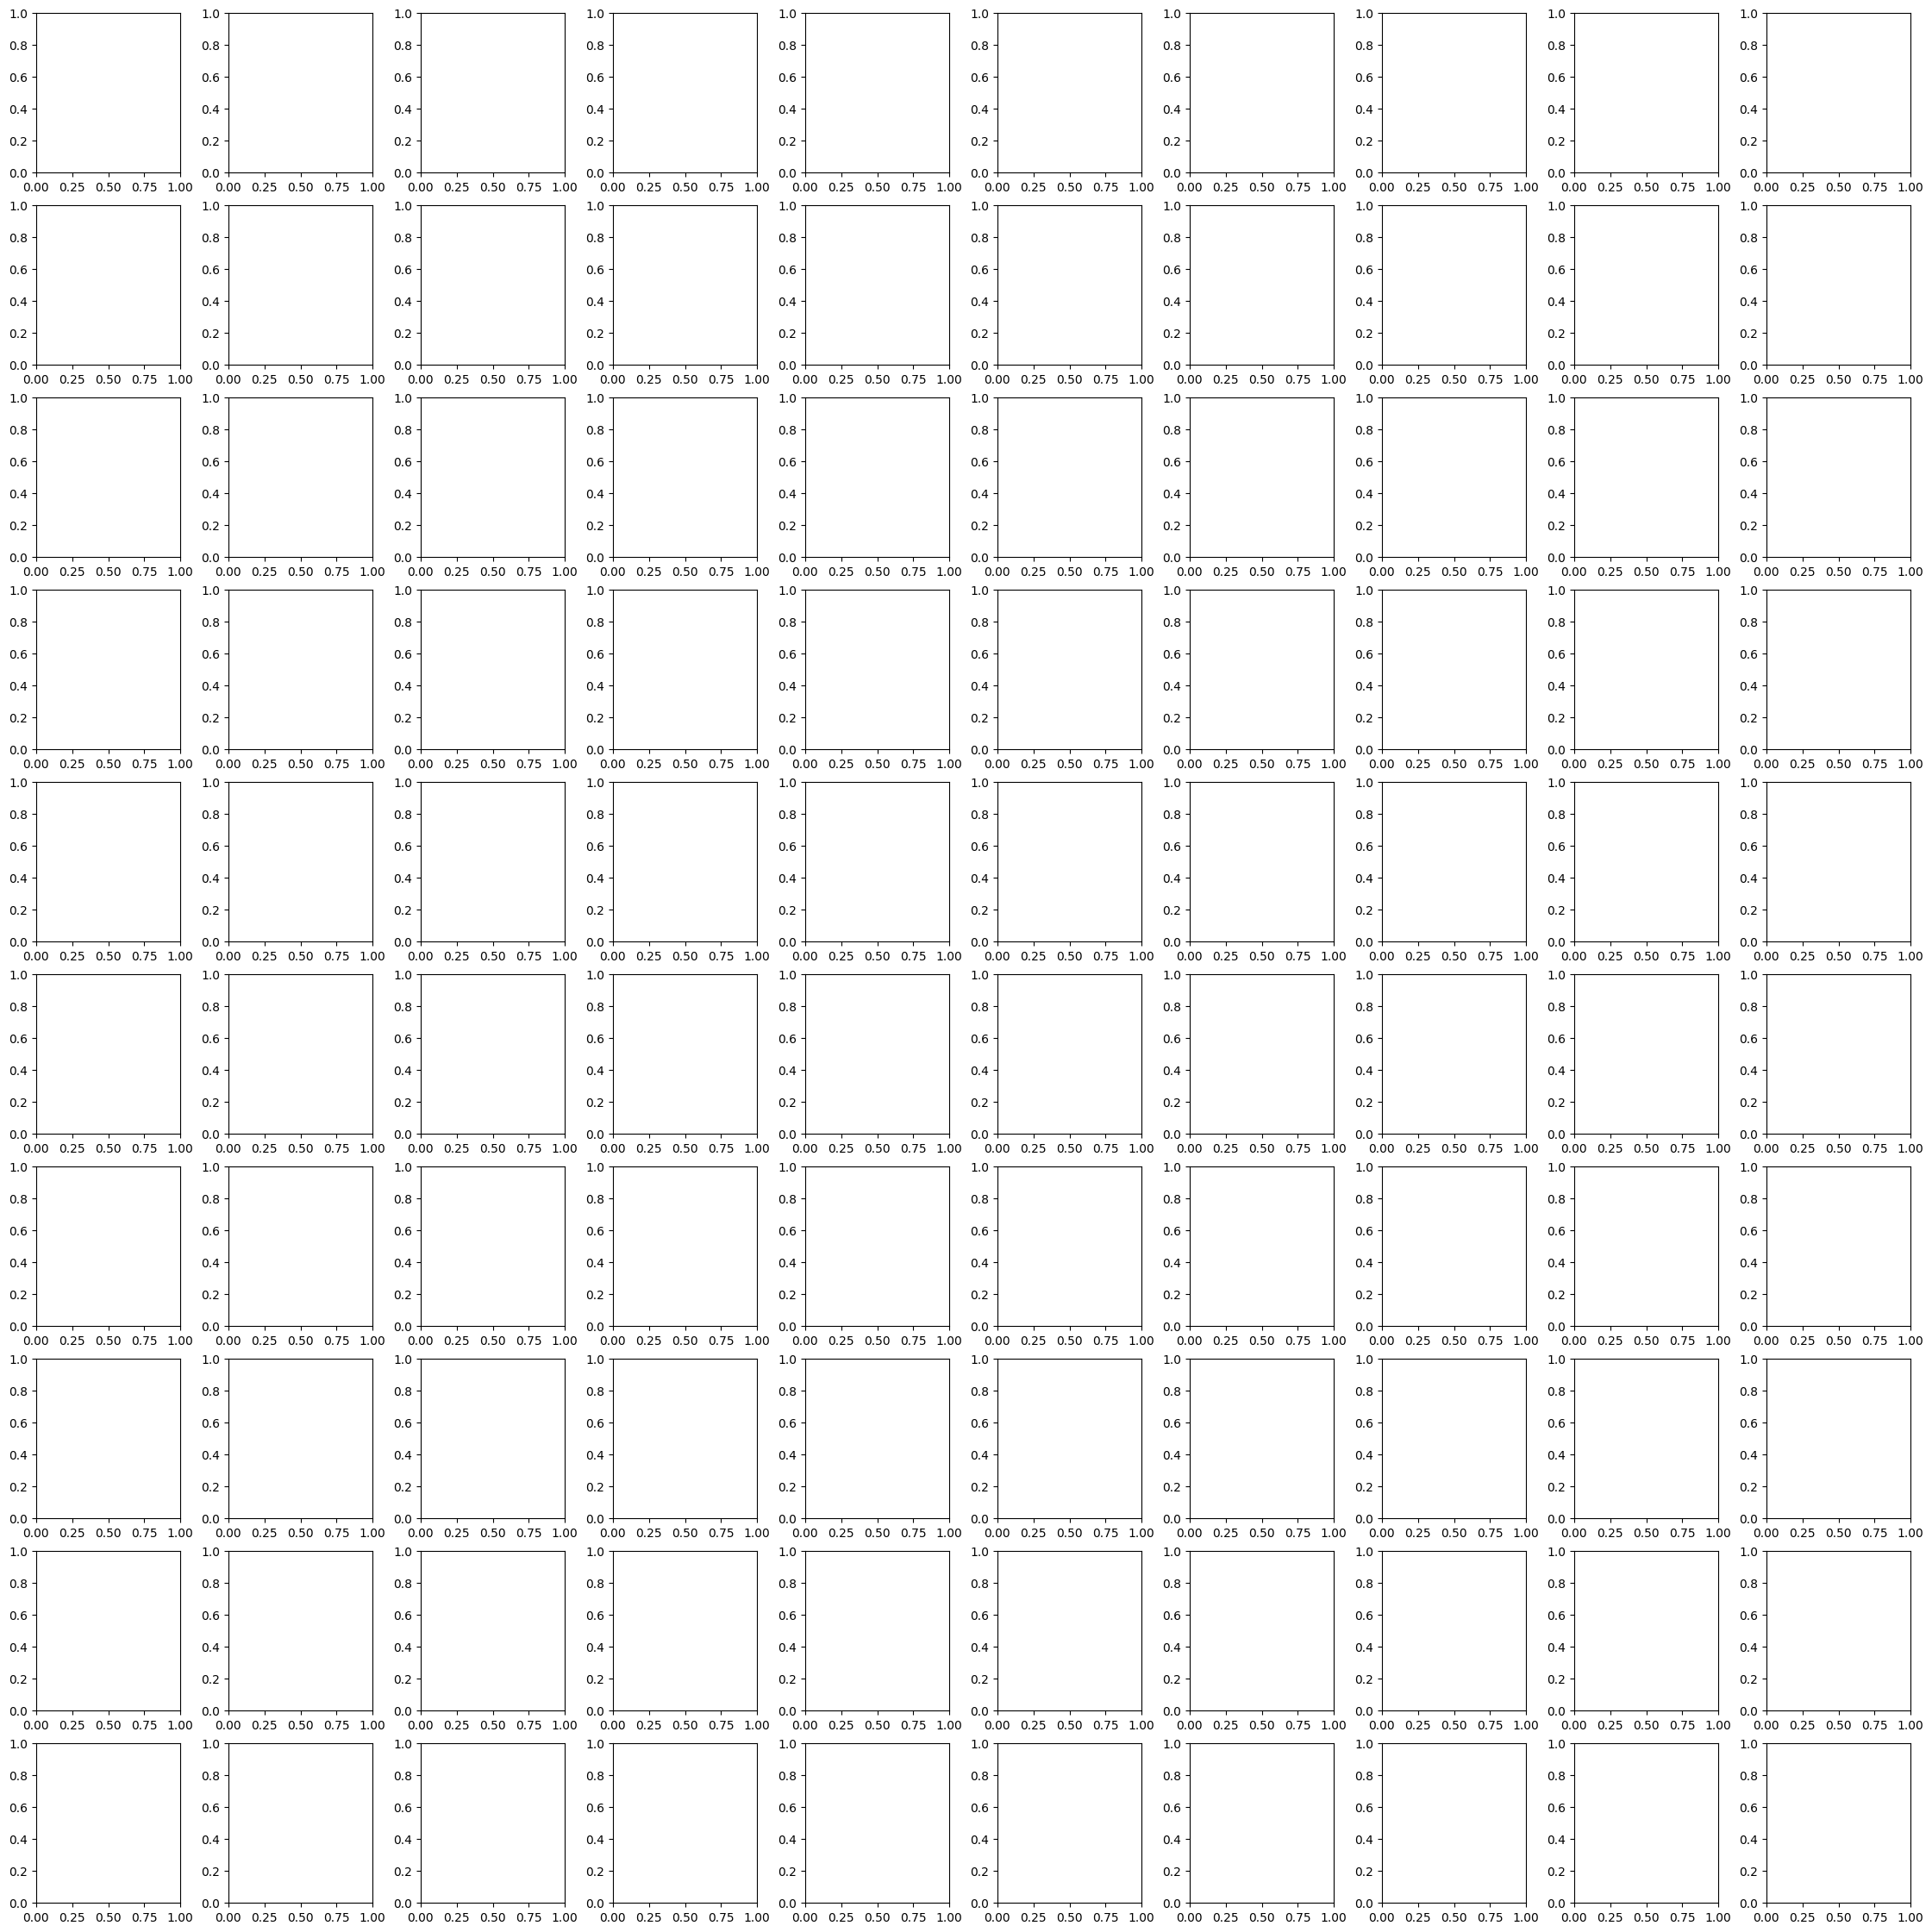

In [6]:
bt_lib = 'NextGenAGSS2009' # GNS93, generic, CIFIST, AGSS2009
n_temps = 2
n_warmup = 4_00
n_samples = 1_000
n_chains = 8
n_check = 2

# Get the model function and callback
model_func, get_max_likelihood = numpyro_model(N_temps=n_temps, return_max_likelihood=True)

model_designation = f'jointvisit_{n_temps}T_{n_samples}_{n_chains}chains_SED_btsettl_{bt_lib}'

rng_key = PRNGKey(42)
# rng_keys = random.split(rng_key, n_chains)

sampler = NUTS(
    model_func,  # Use the returned function
    dense_mass=True
)

mcmc = MCMCWithCheckpoints(
    sampler, 
    num_warmup=n_warmup, 
    num_samples=n_samples,
    num_chains=n_chains
)

mcmc.run_checkpoints(rng_key, n_checkpoints=n_check, on_checkpoint=post_batch_viz_save)

mcmc.print_summary()

# Extract maximum likelihood after sampling
if get_max_likelihood is not None:
    samples = mcmc.get_samples()
    max_log_lik = get_max_likelihood(samples)
    print(f"Maximum log likelihood: {max_log_lik:.6f}")

result = arviz.from_numpyro(mcmc)

In [ ]:
'Save the result'
result.to_netcdf(f'../../data/samples/{model_designation}')

'Print the summary'
arviz.summary(result)

In [ ]:
'Examine the Leave-One-Out (LOO) summary'
loo = arviz.loo(result, pointwise=True)
loo

In [ ]:
# Get the samples from your MCMC run
samples = mcmc.get_samples()  # This gives you all samples

max_likelihood_idx = jnp.argmax(samples['log_likelihood'])

# Extract the maximum likelihood parameters
max_likelihood_params = {}
for key in samples.keys():
    max_likelihood_params[key] = samples[key][max_likelihood_idx]

# Now use max_likelihood_params instead of median_params in your plotting code
spec_G102 = jnp.array(calibrated_mean_spec_G102 + jnp.asarray(max_likelihood_params['offset_G102'], dtype=jnp.float64))
spec_G141 = jnp.array(calibrated_mean_spec_G141)

_spec_flux_jax = jnp.concatenate([
    spec_G102 + max_likelihood_params['slope_G102'] * (SED_wavelengths_G102 - SED_wavelengths_G102[0]),
    spec_G141 + max_likelihood_params['slope_G141'] * (SED_wavelengths_G141 - SED_wavelengths_G141[0]) 
])

max_likelihood_spec_flux = _spec_flux_jax / jnp.mean(_spec_flux_jax)
max_likelihood_spec_err = jnp.concatenate([
    jnp.array(oot_spec_err_G102 * jnp.asarray(10**max_likelihood_params[r'beta_G102'], dtype=jnp.float64)),
    jnp.array(oot_spec_err_G141 * jnp.asarray(10**max_likelihood_params[r'beta_G141'], dtype=jnp.float64))
])
combined_SED_wavelengths = jnp.concatenate([jnp.array(SED_wavelengths_G102), jnp.array(SED_wavelengths_G141)])

filter_sigma = 1.0  #max_likelihood_params['sigma_conv']

temps = []
for i in range(1, n_temps + 1):
    temp_key = f'T{i}'
    temps.append(jnp.asarray(max_likelihood_params[temp_key], dtype=jnp.float64))

# Get spectra for all temperature components
log_g = 4.5
metal = max_likelihood_params['metal']
spectra = [get_BTSettl_spectrum_jax(T=Temp, logg=log_g, metallicity=metal) 
                       for Temp in temps]

# Get scale factors
scales = [1.0]
for i in range(2, n_temps + 1):
    ff_key = f'ff{i}'
    scale = jnp.asarray(10**max_likelihood_params[ff_key], dtype=jnp.float64)
    scales.append(scale)

# Calculate combined spectrum
_max_likelihood_flux = scales[0] * spectra[0][1]
for i in range(1, n_temps):
    _max_likelihood_flux += scales[i] * spectra[i][1]

_model_flux = _max_likelihood_flux / jnp.mean(_max_likelihood_flux)
convolved = convolve_spectrum_jax(panchromatic_wavelengths, _model_flux, sigma=filter_sigma)
binned_model_flux = shone.bin_spectrum(combined_SED_wavelengths, panchromatic_wavelengths, convolved)
max_likelihood_model_flux = (binned_model_flux / jnp.mean(binned_model_flux))

# Plot with maximum likelihood parameters
fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True, gridspec_kw={'height_ratios': [3, 1]})
fig.suptitle(r'0.8-1.64 $\mu$m SED with ' + f'{n_temps}T Model (Maximum Likelihood)', fontsize=20)
axs[1].set_title('Residuals', fontsize=14)
axs[1].set_xlim(0.805, 1.645)
axs[1].set_ylim(-4, 4)
axs[1].set_xlabel(r'Wavelength ($\mu$m)', fontsize=14)
axs[0].set_ylabel('Relative Flux', fontsize=14)
axs[1].set_ylabel(r'$\sigma$', fontsize=14)

axs[0].errorbar(combined_SED_wavelengths,
                max_likelihood_spec_flux,
                yerr=max_likelihood_spec_err,
                fmt='o', color='b', ms=1, alpha=0.7)
axs[0].plot(combined_SED_wavelengths,
            max_likelihood_model_flux, color='k', zorder=100)
axs[1].scatter(combined_SED_wavelengths,
               (max_likelihood_model_flux - max_likelihood_spec_flux) / max_likelihood_spec_err,
               color='gray')
axs[1].axhline(0, color='k', zorder=-100)

plt.savefig(f'../../figs/{model_designation}_max_likelihood_result.png', dpi=200)

## Run 3T Model

In [ ]:
bt_lib = 'NextGenAGSS2009' # GNS93, generic, CIFIST, AGSS2009
n_temps = 3
n_warmup = 4_00
n_samples = 2_000
n_chains = 8
n_check = 2

# Get the model function and callback
model_func, get_max_likelihood = numpyro_model(N_temps=n_temps, return_max_likelihood=True)

model_designation = f'jointvisit_{n_temps}T_{n_samples}_{n_chains}chains_SED_btsettl_{bt_lib}'

rng_key = PRNGKey(42)
# rng_keys = random.split(rng_key, n_chains)

sampler = NUTS(
    model_func,  # Use the returned function
    dense_mass=True
)

mcmc = MCMCWithCheckpoints(
    sampler, 
    num_warmup=n_warmup, 
    num_samples=n_samples,
    num_chains=n_chains
)

mcmc.run_checkpoints(rng_key, n_checkpoints=n_check, on_checkpoint=post_batch_viz_save)

mcmc.print_summary()

# Extract maximum likelihood after sampling
if get_max_likelihood is not None:
    samples = mcmc.get_samples()
    max_log_lik = get_max_likelihood(samples)
    print(f"Maximum log likelihood: {max_log_lik:.6f}")

result = arviz.from_numpyro(mcmc)

# Post-Inference Analysis

In [ ]:
'Save the result'
result.to_netcdf(f'../../data/samples/{model_designation}')

'Print the summary'
arviz.summary(result)

In [ ]:
'Examine the Leave-One-Out (LOO) summary'
loo = arviz.loo(result, pointwise=True)
loo

In [ ]:
'Extract median result'
median_params = arviz.summary(result,stat_focus='median')['median']

In [ ]:
# 'Make a corner plot'
# corner.corner(
#     result, var_names=['~offset_G102',
#                        r'~$\beta_{\rm G102}$',
#                        r'~$\beta_{\rm G141}$',
#                        r'~$\sigma_{\rm conv}$'],
#     # quiet=True, 
# );
# plt.savefig(f'../../figs/{model_designation}_corner.png',dpi=200)

In [ ]:
# Get the samples from your MCMC run
samples = mcmc.get_samples()  # This gives you all samples

max_likelihood_idx = jnp.argmax(samples['log_likelihood'])

# Extract the maximum likelihood parameters
max_likelihood_params = {}
for key in samples.keys():
    max_likelihood_params[key] = samples[key][max_likelihood_idx]

# Now use max_likelihood_params instead of median_params in your plotting code
spec_G102 = jnp.array(calibrated_mean_spec_G102 + jnp.asarray(max_likelihood_params['offset_G102'], dtype=jnp.float64))
spec_G141 = jnp.array(calibrated_mean_spec_G141)

_spec_flux_jax = jnp.concatenate([
    spec_G102 + max_likelihood_params['slope_G102'] * (SED_wavelengths_G102 - SED_wavelengths_G102[0]),
    spec_G141 + max_likelihood_params['slope_G141'] * (SED_wavelengths_G141 - SED_wavelengths_G141[0]) 
])

max_likelihood_spec_flux = _spec_flux_jax / jnp.mean(_spec_flux_jax)
max_likelihood_spec_err = jnp.concatenate([
    jnp.array(oot_spec_err_G102 * jnp.asarray(10**max_likelihood_params[r'beta_G102'], dtype=jnp.float64)),
    jnp.array(oot_spec_err_G141 * jnp.asarray(10**max_likelihood_params[r'beta_G141'], dtype=jnp.float64))
])
combined_SED_wavelengths = jnp.concatenate([jnp.array(SED_wavelengths_G102), jnp.array(SED_wavelengths_G141)])

filter_sigma = 1.0  #max_likelihood_params['sigma_conv']

temps = []
for i in range(1, n_temps + 1):
    temp_key = f'T{i}'
    temps.append(jnp.asarray(max_likelihood_params[temp_key], dtype=jnp.float64))

# Get spectra for all temperature components
log_g = 4.5
metal = max_likelihood_params['metal']
spectra = [get_BTSettl_spectrum_jax(T=Temp, logg=log_g, metallicity=metal) 
                       for Temp in temps]

# Get scale factors
scales = [1.0]
for i in range(2, n_temps + 1):
    ff_key = f'ff{i}'
    scale = jnp.asarray(10**max_likelihood_params[ff_key], dtype=jnp.float64)
    scales.append(scale)

# Calculate combined spectrum
_max_likelihood_flux = scales[0] * spectra[0][1]
for i in range(1, n_temps):
    _max_likelihood_flux += scales[i] * spectra[i][1]

_model_flux = _max_likelihood_flux / jnp.mean(_max_likelihood_flux)
convolved = convolve_spectrum_jax(panchromatic_wavelengths, _model_flux, sigma=filter_sigma)
binned_model_flux = shone.bin_spectrum(combined_SED_wavelengths, panchromatic_wavelengths, convolved)
max_likelihood_model_flux = (binned_model_flux / jnp.mean(binned_model_flux))

# Plot with maximum likelihood parameters
fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True, gridspec_kw={'height_ratios': [3, 1]})
fig.suptitle(r'0.8-1.64 $\mu$m SED with ' + f'{n_temps}T Model (Maximum Likelihood)', fontsize=20)
axs[1].set_title('Residuals', fontsize=14)
axs[1].set_xlim(0.805, 1.645)
axs[1].set_ylim(-4, 4)
axs[1].set_xlabel(r'Wavelength ($\mu$m)', fontsize=14)
axs[0].set_ylabel('Relative Flux', fontsize=14)
axs[1].set_ylabel(r'$\sigma$', fontsize=14)

axs[0].errorbar(combined_SED_wavelengths,
                max_likelihood_spec_flux,
                yerr=max_likelihood_spec_err,
                fmt='o', color='b', ms=1, alpha=0.7)
axs[0].plot(combined_SED_wavelengths,
            max_likelihood_model_flux, color='k', zorder=100)
axs[1].scatter(combined_SED_wavelengths,
               (max_likelihood_model_flux - max_likelihood_spec_flux) / max_likelihood_spec_err,
               color='gray')
axs[1].axhline(0, color='k', zorder=-100)

plt.savefig(f'../../figs/{model_designation}_max_likelihood_result.png', dpi=200)

# Compare multiple models of the same dataset

In [ ]:
compare_dict = {}

compare_dict['model_1'] = arviz.InferenceData.from_netcdf('../../data/samples/jointvisit_3T_2000_6chains_SED_btsettl_NextGenAGSS2009')
compare_dict['model_2'] = arviz.InferenceData.from_netcdf('../../data/samples/jointvisit_2T_2000_6chains_SED_btsettl_NextGenAGSS2009')
compare_dict['model_3'] = arviz.InferenceData.from_netcdf('../../data/samples/jointvisit_1T_2000_6chains_SED_btsettl_NextGenAGSS2009')
# compare_dict['model_4'] = arviz.InferenceData.from_netcdf('../../data/samples/jointvisit_2T_2000_6chains_SED_btsettl_Generic')
# compare_dict['model_3'] = arviz.InferenceData.from_netcdf('../../data/samples/')

arviz.compare(compare_dict)

From https://num.pyro.ai/en/latest/tutorials/bad_posterior_geometry.html

In general it is difficult to assess whether the samples returned from HMC or NUTS represent accurate (approximate) samples from the posterior. Two general rules of thumb, however, are to look at the effective sample size (ESS) and r_hat diagnostics returned by mcmc.print_summary(). If we see values of r_hat in the range (1.0, 1.05) and effective sample sizes that are comparable to the total number of samples num_samples (assuming thinning=1) then we have good reason to believe that HMC is doing a good job. If, however, we see low effective sample sizes or large r_hats for some of the variables (e.g. r_hat = 1.15) then HMC is likely struggling with the posterior geometry. In the following we will use r_hat as our primary diagnostic metric.